##  **IPL 2026 Scouting & Player Analysis**


---


## Data Analyst Portfolio Project







## Section 1 — Setup & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import json
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
zip_path = '/content/drive/MyDrive/IPL_Project/ipl_json.zip'

## Section 2 — Reading Files


In [4]:
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    json_files = [f for f in all_files if f.endswith('.json')]

print(f"Total match files found: {len(json_files)}")

Total match files found: 1243


## Section 3 — Matches Table


In [5]:
matches_list = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for filename in json_files:
        with z.open(filename) as f:
            data = json.load(f)

            match_row = {
                'match_id'      : filename.replace('.json', ''),
                'date'          : data['info']['dates'][0],
                'season'        : data['info']['season'],
                'venue'         : data['info']['venue'],
                'city'          : data['info'].get('city', None),
                'team1'         : data['info']['teams'][0],
                'team2'         : data['info']['teams'][1],
                'toss_winner'   : data['info']['toss']['winner'],
                'toss_decision' : data['info']['toss']['decision'],
                'winner'        : data['info']['outcome'].get('winner', None)
            }

            matches_list.append(match_row)

matches_df = pd.DataFrame(matches_list)
print(f"Matches loaded: {matches_df.shape}")
print(matches_df.head())

Matches loaded: (1243, 10)
  match_id        date season                                      venue  \
0  1082591  2017-04-05   2017  Rajiv Gandhi International Stadium, Uppal   
1  1082592  2017-04-06   2017    Maharashtra Cricket Association Stadium   
2  1082593  2017-04-07   2017     Saurashtra Cricket Association Stadium   
3  1082594  2017-04-08   2017                     Holkar Cricket Stadium   
4  1082595  2017-04-08   2017                      M.Chinnaswamy Stadium   

        city                        team1                        team2  \
0  Hyderabad          Sunrisers Hyderabad  Royal Challengers Bangalore   
1       Pune       Rising Pune Supergiant               Mumbai Indians   
2     Rajkot                Gujarat Lions        Kolkata Knight Riders   
3     Indore              Kings XI Punjab       Rising Pune Supergiant   
4  Bengaluru  Royal Challengers Bangalore             Delhi Daredevils   

                   toss_winner toss_decision                       winn

## Section 4 — Deliveries Table


In [6]:
deliveries_list = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for filename in json_files:
        with z.open(filename) as f:
            data = json.load(f)
            for i, innings in enumerate(data['innings']):
                match_teams = data['info']['teams']
                for over in innings['overs']:
                    for ball_number, delivery in enumerate(over['deliveries']):
                        delivery_data = {
                            'match_id'       : filename.replace('.json', ''),
                            'season'         : data['info']['season'],
                            'innings_number' : i + 1,
                            'over'           : over['over'],
                            'ball'           : ball_number + 1,
                            'venue'          : data['info']['venue'],
                            'batting_team'   : innings['team'],
                            'bowling_team'   : match_teams[1] if innings['team'] == match_teams[0] else match_teams[0],
                            'batter'         : delivery['batter'],
                            'bowler'         : delivery['bowler'],
                            'runs_batter'    : delivery['runs']['batter'],
                            'runs_extras'    : delivery['runs']['extras'],
                            'runs_total'     : delivery['runs']['total'],
                            'is_wicket'      : 1 if 'wickets' in delivery else 0,
                            'player_out'     : delivery['wickets'][0]['player_out'] if 'wickets' in delivery else None,
                            'wicket_kind'    : delivery['wickets'][0]['kind'] if 'wickets' in delivery else None,
                        }
                        deliveries_list.append(delivery_data)

deliveries_df = pd.DataFrame(deliveries_list)
print(f"Deliveries loaded: {deliveries_df.shape}")
print(deliveries_df.head())

Deliveries loaded: (295732, 16)
  match_id season  innings_number  over  ball  \
0  1082591   2017               1     0     1   
1  1082591   2017               1     0     2   
2  1082591   2017               1     0     3   
3  1082591   2017               1     0     4   
4  1082591   2017               1     0     5   

                                       venue         batting_team  \
0  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
1  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
2  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
3  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
4  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   

                  bowling_team     batter    bowler  runs_batter  runs_extras  \
0  Royal Challengers Bangalore  DA Warner  TS Mills            0            0   
1  Royal Challengers Bangalore  DA Warner  TS Mills            0            0   
2  Royal Challe

In [7]:
# Save both tables to Google Drive
matches_df.to_csv('/content/drive/MyDrive/IPL_Project/matches.csv', index=False)
deliveries_df.to_csv('/content/drive/MyDrive/IPL_Project/deliveries.csv', index=False)
print("Both CSVs saved to Drive")

Both CSVs saved to Drive


## Section 5 — Load into SQLite


In [8]:
conn = sqlite3.connect('ipl.db')

matches_df.to_sql('matches', conn, if_exists='replace', index=False)
deliveries_df.to_sql('deliveries', conn, if_exists='replace', index=False)

print("SQLite loaded — ready for analysis")

SQLite loaded — ready for analysis


## Section 6 — Business Analysis Queries


>

### BQ1 — Top Run Scorers IPL 2026

In [9]:
query = '''
SELECT batter,
       SUM(runs_batter) as total_runs,
       ROUND(SUM(runs_batter) * 100.0 / COUNT(ball), 2) as strike_rate
FROM deliveries
WHERE season = 2026
GROUP BY batter
HAVING COUNT(ball) >= 100
ORDER BY total_runs DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print(result)

            batter  total_runs  strike_rate
0    V Suryavanshi         776       225.58
1     Shubman Gill         732       155.08
2  B Sai Sudharsan         722       150.10
3          V Kohli         675       158.82
4        H Klaasen         624       151.09
5     Ishan Kishan         602       176.02
6         KL Rahul         593       167.04
7         MR Marsh         563       157.26
8  Abhishek Sharma         563       185.20
9       JC Buttler         526       149.43


### BQ2 — Player Consistency (Half Centuries & Centuries)

In [10]:
query = '''
SELECT batter,
       COUNT(*) as innings,
       COUNT(CASE WHEN innings_runs >= 50 THEN 1 END) as half_centuries,
       COUNT(CASE WHEN innings_runs >= 100 THEN 1 END) as centuries
FROM (
    SELECT batter, match_id, innings_number,
           SUM(runs_batter) as innings_runs
    FROM deliveries
    WHERE season = 2026
    GROUP BY batter, match_id, innings_number
) as innings_table
GROUP BY batter
HAVING COUNT(*) >= 10
ORDER BY half_centuries DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print(result)

            batter  innings  half_centuries  centuries
0  B Sai Sudharsan       17               9          1
1     Shubman Gill       16               7          1
2    V Suryavanshi       16               6          1
3          V Kohli       16               6          1
4          SS Iyer       13               6          1
5   P Simran Singh       13               6          0
6         KL Rahul       14               6          1
7     Ishan Kishan       15               6          0
8        H Klaasen       15               6          0
9      Dhruv Jurel       16               6          0


### BQ3 — Top Wicket Takers IPL 2026

In [11]:
query = '''
SELECT bowler, bowling_team,
       SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) as total_wickets,
       ROUND(CAST(COUNT(ball) AS REAL) /
           NULLIF(SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END), 0), 2) as bowling_sr,
       ROUND(CAST(SUM(runs_total) AS REAL) /
           NULLIF(SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END), 0), 2) as bowling_avg,
       ROUND(CAST(SUM(runs_total) AS REAL) * 6 / COUNT(ball), 2) as economy_rate
FROM deliveries
WHERE season = 2026
GROUP BY bowler
HAVING COUNT(ball) >= 24
ORDER BY total_wickets DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print(result)

           bowler                 bowling_team  total_wickets  bowling_sr  \
0        K Rabada               Gujarat Titans             29       13.79   
1         B Kumar  Royal Challengers Bengaluru             28       13.96   
2       JC Archer             Rajasthan Royals             25       15.16   
3     Rashid Khan               Gujarat Titans             21       16.57   
4        A Kamboj          Chennai Super Kings             21       15.00   
5       E Malinga          Sunrisers Hyderabad             20       17.55   
6    Rasikh Salam  Royal Challengers Bengaluru             19       14.32   
7  Mohammed Siraj               Gujarat Titans             19       20.32   
8    Kartik Tyagi        Kolkata Knight Riders             18       17.61   
9       SP Narine        Kolkata Knight Riders             17       18.18   

   bowling_avg  economy_rate  
0        21.76          9.47  
1        18.00          7.73  
2        22.64          8.96  
3        25.10          9.09

### BQ4 — Venue match averages (Ground Conditions)




In [12]:
query = '''
SELECT venue,
       COUNT(*) as matches_played,
       ROUND(AVG(match_runs), 1) as avg_runs_per_match,
       ROUND(AVG(match_wickets), 1) as avg_wickets_per_match
FROM (
    SELECT match_id, venue,
           SUM(runs_total) as match_runs,
           SUM(is_wicket) as match_wickets
    FROM deliveries
    WHERE season = 2026
    GROUP BY match_id, venue
)
GROUP BY venue
ORDER BY avg_runs_per_match DESC
'''
result = pd.read_sql(query, conn)
print(result)

                                                venue  matches_played  \
0                      Sawai Mansingh Stadium, Jaipur               4   
1   Maharaja Yadavindra Singh International Cricke...               6   
2                            Wankhede Stadium, Mumbai               7   
3   Himachal Pradesh Cricket Association Stadium, ...               4   
4   Rajiv Gandhi International Stadium, Uppal, Hyd...               7   
5                    M Chinnaswamy Stadium, Bengaluru               5   
6            MA Chidambaram Stadium, Chepauk, Chennai               7   
7   Shaheed Veer Narayan Singh International Stadi...               2   
8                         Arun Jaitley Stadium, Delhi               7   
9   Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...               7   
10                   Narendra Modi Stadium, Ahmedabad               8   
11                              Eden Gardens, Kolkata               7   
12                Barsapara Cricket Stadium, Guwaha

### BQ5 — Death Over Specialists (Overs 17-20)

In [13]:
# Death batting
query = '''
SELECT batter,
       SUM(runs_batter) as total_runs,
       ROUND(SUM(runs_batter) * 100.0 / COUNT(ball), 2) as strike_rate
FROM deliveries
WHERE season = 2026 AND over >= 16
GROUP BY batter
HAVING COUNT(ball) >= 30
ORDER BY strike_rate DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print("DEATH OVER BATTERS:")
print(result)

DEATH OVER BATTERS:
                batter  total_runs  strike_rate
0          Tilak Varma         137       268.63
1           D Ferreira         161       247.69
2             TH David         156       219.72
3           MP Stoinis         106       207.84
4  Nithish Kumar Reddy         112       207.41
5      Ashutosh Sharma         134       203.03
6            DA Miller         100       200.00
7        A Raghuvanshi          66       194.12
8              RR Pant          72       189.47
9             RK Singh         154       187.80


In [14]:
# Death bowling
query = '''
SELECT bowler,
       SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) as total_wickets,
       ROUND(CAST(COUNT(ball) AS REAL) /
           NULLIF(SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END), 0), 2) as bowling_sr,
       ROUND(CAST(SUM(runs_total) AS REAL) * 6 / COUNT(ball), 2) as economy_rate
FROM deliveries
WHERE season = 2026 AND over >= 16
GROUP BY bowler
HAVING COUNT(ball) >= 24
ORDER BY economy_rate ASC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print("DEATH OVER BOWLERS:")
print(result)

DEATH OVER BOWLERS:
              bowler  total_wickets  bowling_sr  economy_rate
0          JO Holder              4        6.75          5.78
1         PJ Cummins              1       24.00          7.75
2            L Ngidi              6       13.67          7.83
3          JJ Bumrah              1       70.00          7.97
4      Sakib Hussain              7       12.29          8.23
5            B Kumar              9       12.33          8.32
6           N Burger              4       11.00          8.32
7        Harsh Dubey              5        6.00          8.60
8           VG Arora              6       15.33          8.67
9  Vijaykumar Vyshak              4        9.50          8.68


### BQ6 — Powerplay Specialists (Overs 1-6)

In [15]:
# Powerplay batting
query = '''
SELECT batter,
       SUM(runs_batter) as total_runs,
       ROUND(SUM(runs_batter) * 100.0 / COUNT(ball), 2) as strike_rate
FROM deliveries
WHERE season = 2026 AND over <= 5
GROUP BY batter
HAVING COUNT(ball) >= 30
ORDER BY strike_rate DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print("POWERPLAY BATTERS:")
print(result)

POWERPLAY BATTERS:
            batter  total_runs  strike_rate
0    V Suryavanshi         521       221.70
1          VR Iyer          95       220.93
2        JP Inglis         179       215.66
3      Urvil Patel         102       208.16
4    Priyansh Arya         294       201.37
5  Abhishek Sharma         369       193.19
6          SN Khan          83       176.60
7     Ishan Kishan         187       176.42
8         FH Allen         207       175.42
9       D Padikkal         245       173.76


In [16]:
# Powerplay bowling
query = '''
SELECT bowler,
       SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) as total_wickets,
       ROUND(CAST(COUNT(ball) AS REAL) /
           NULLIF(SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END), 0), 2) as bowling_sr,
       ROUND(CAST(SUM(runs_total) AS REAL) * 6 / COUNT(ball), 2) as economy_rate
FROM deliveries
WHERE season = 2026 AND over <= 5
GROUP BY bowler
HAVING COUNT(ball) >= 24
ORDER BY total_wickets DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print("POWERPLAY BOWLERS:")
print(result)

POWERPLAY BOWLERS:
           bowler  total_wickets  bowling_sr  economy_rate
0        K Rabada             20       13.95          9.68
1         B Kumar             17       12.47          6.74
2  Mohammed Siraj             15       19.27          7.97
3       JC Archer             14       15.57          9.52
4  Mohammed Shami              9       21.78          7.29
5        N Burger              7       23.71         10.05
6    JR Hazlewood              7       23.00          9.84
7  Arshdeep Singh              7       26.00          8.57
8    AM Ghazanfar              7        8.71         10.62
9    Prince Yadav              6       20.50          8.24


### BQ7 — Window Functions: Player Rankings

In [17]:
query = '''
SELECT batter, total_runs, strike_rate,
       RANK() OVER (ORDER BY total_runs DESC) as runs_rank,
       RANK() OVER (ORDER BY strike_rate DESC) as sr_rank
FROM (
    SELECT batter,
           SUM(runs_batter) as total_runs,
           ROUND(SUM(runs_batter) * 100.0 / COUNT(ball), 2) as strike_rate
    FROM deliveries
    WHERE season = 2026
    GROUP BY batter
    HAVING COUNT(ball) >= 100
)
ORDER BY runs_rank
LIMIT 15
'''
result = pd.read_sql(query, conn)
print(result)

             batter  total_runs  strike_rate  runs_rank  sr_rank
0     V Suryavanshi         776       225.58          1        1
1      Shubman Gill         732       155.08          2       27
2   B Sai Sudharsan         722       150.10          3       32
3           V Kohli         675       158.82          4       24
4         H Klaasen         624       151.09          5       31
5      Ishan Kishan         602       176.02          6       10
6          KL Rahul         593       167.04          7       14
7   Abhishek Sharma         563       185.20          8        4
8          MR Marsh         563       157.26          8       25
9        JC Buttler         526       149.43         10       33
10      Dhruv Jurel         515       149.28         11       34
11   P Simran Singh         510       161.39         12       22
12       RM Patidar         501       181.52         13        5
13          SS Iyer         498       162.75         14       19
14       C Connolly      

### BQ8 — Window Functions: Top Scorer Per Team (PARTITION BY)

In [18]:
query = '''
SELECT *
FROM (
    SELECT batting_team, batter, total_runs,
           ROW_NUMBER() OVER (PARTITION BY batting_team ORDER BY total_runs DESC) as team_rank
    FROM (
        SELECT batting_team, batter, SUM(runs_batter) as total_runs
        FROM deliveries
        WHERE season = 2026
        GROUP BY batting_team, batter
    )
)
WHERE team_rank = 1
ORDER BY total_runs DESC
'''
result = pd.read_sql(query, conn)
print(result)

                  batting_team          batter  total_runs  team_rank
0             Rajasthan Royals   V Suryavanshi         776          1
1               Gujarat Titans    Shubman Gill         732          1
2  Royal Challengers Bengaluru         V Kohli         675          1
3          Sunrisers Hyderabad       H Klaasen         624          1
4               Delhi Capitals        KL Rahul         593          1
5         Lucknow Super Giants        MR Marsh         563          1
6                 Punjab Kings  P Simran Singh         510          1
7          Chennai Super Kings       SV Samson         477          1
8               Mumbai Indians    RD Rickelton         448          1
9        Kolkata Knight Riders   A Raghuvanshi         422          1


### BQ9 — JOIN: Toss Decision vs Venue Scoring

In [19]:
query = '''
SELECT m.venue,
       m.toss_decision,
       COUNT(DISTINCT d.match_id) as matches,
       ROUND(SUM(d.runs_total) * 1.0 / COUNT(DISTINCT d.match_id), 1) as avg_runs
FROM deliveries d
JOIN matches m ON d.match_id = m.match_id
WHERE m.season = 2026 AND d.innings_number = 1
GROUP BY m.venue, m.toss_decision
ORDER BY m.venue, m.toss_decision
'''
result = pd.read_sql(query, conn)
print(result)

                                                venue toss_decision  matches  \
0                         Arun Jaitley Stadium, Delhi           bat        2   
1                         Arun Jaitley Stadium, Delhi         field        5   
2                 Barsapara Cricket Stadium, Guwahati         field        3   
3   Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...         field        7   
4                               Eden Gardens, Kolkata           bat        2   
5                               Eden Gardens, Kolkata         field        5   
6   Himachal Pradesh Cricket Association Stadium, ...         field        4   
7                    M Chinnaswamy Stadium, Bengaluru         field        5   
8            MA Chidambaram Stadium, Chepauk, Chennai           bat        2   
9            MA Chidambaram Stadium, Chepauk, Chennai         field        5   
10  Maharaja Yadavindra Singh International Cricke...           bat        1   
11  Maharaja Yadavindra Singh Internatio

### BQ10 — Home Venue Analysis: CSK

In [20]:
query = '''
SELECT d.batter,
       COUNT(DISTINCT d.match_id) as matches_played,
       SUM(d.runs_batter) as total_runs,
       ROUND(SUM(d.runs_batter) * 100.0 / COUNT(d.ball), 2) as strike_rate
FROM deliveries d
JOIN matches m ON d.match_id = m.match_id
WHERE m.season = 2026
AND d.venue = 'MA Chidambaram Stadium, Chepauk, Chennai'
AND d.innings_number = 1
GROUP BY d.batter
ORDER BY total_runs DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print(result)

          batter  matches_played  total_runs  strike_rate
0      SV Samson               5         208       163.78
1       A Mhatre               3         170       171.72
2     RD Gaikwad               5         139       104.51
3         S Dube               5         126       124.75
4       D Brevis               3          87       124.29
5      JP Inglis               1          85       250.00
6     Naman Dhir               1          57       154.05
7        SN Khan               3          55       166.67
8  Kartik Sharma               3          48       154.84
9  Shahbaz Ahmed               1          43       172.00


## Section 7 - Data visualization

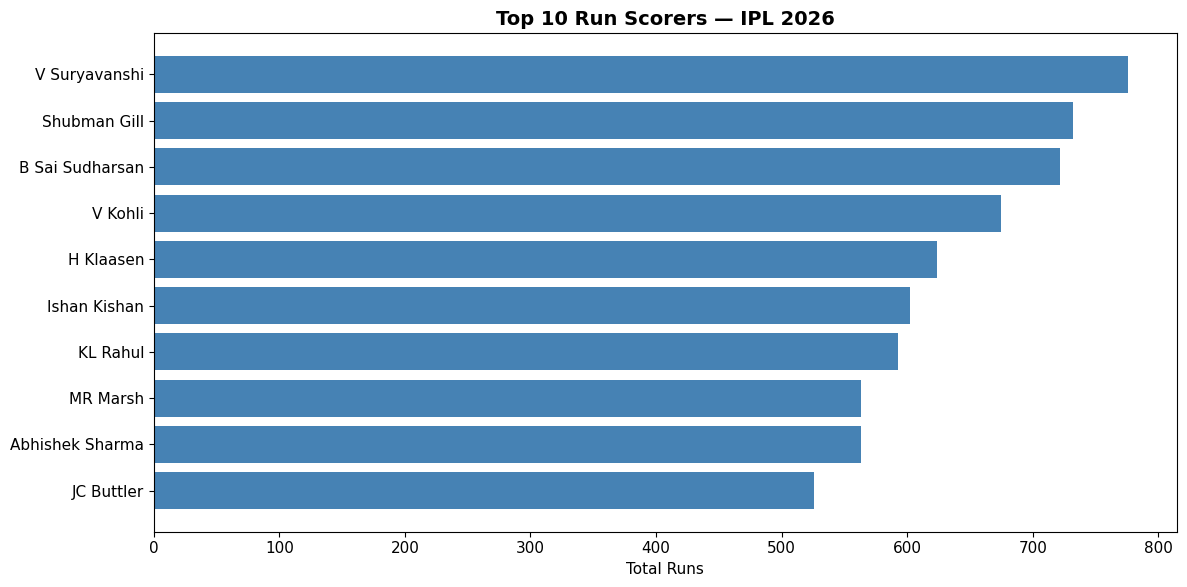

In [21]:
# Query first
query = '''
SELECT batter, SUM(runs_batter) as total_runs
FROM deliveries
WHERE season = 2026
GROUP BY batter
HAVING COUNT(ball) >= 100
ORDER BY total_runs DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)

# Then plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(result['batter'], result['total_runs'], color='steelblue')
ax.set_title('Top 10 Run Scorers — IPL 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Runs')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

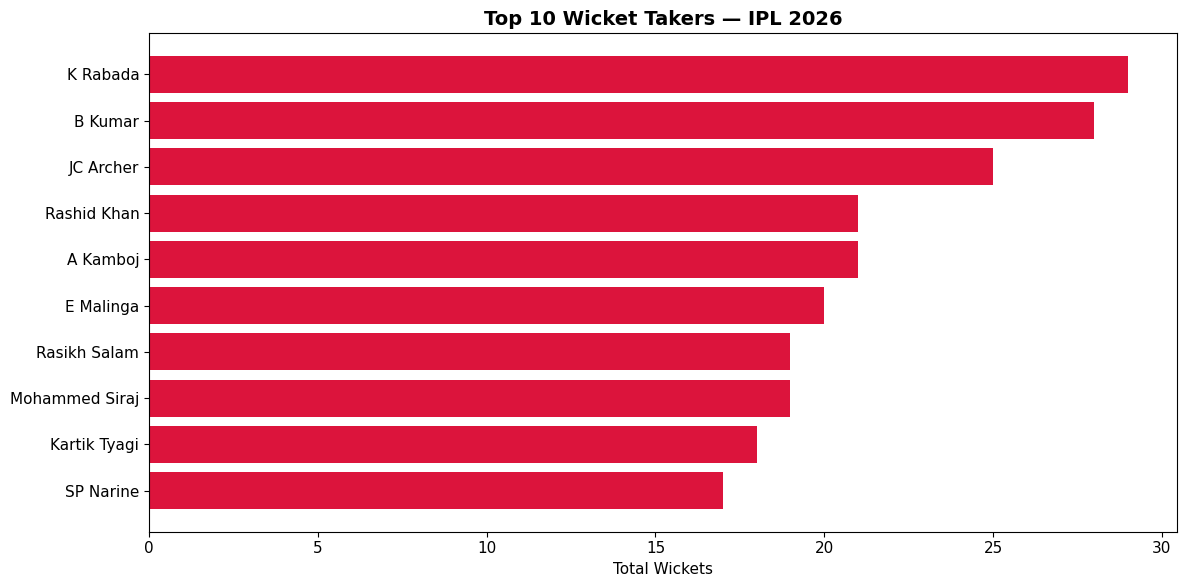

In [22]:
query = '''
SELECT bowler,
       SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) as total_wickets
FROM deliveries
WHERE season = 2026
GROUP BY bowler
HAVING COUNT(ball) >= 24
ORDER BY total_wickets DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(result['bowler'], result['total_wickets'], color='crimson')
ax.set_title('Top 10 Wicket Takers — IPL 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Wickets')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Section 8 — Export Derived Datasets


In [23]:
# Batsman per-match stats
query = '''
SELECT match_id, batter, batting_team, bowling_team, venue,
       SUM(runs_batter) as runs,
       COUNT(ball) as balls_faced,
       SUM(CASE WHEN runs_batter = 4 THEN 1 ELSE 0 END) as fours,
       SUM(CASE WHEN runs_batter = 6 THEN 1 ELSE 0 END) as sixes,
       ROUND(SUM(runs_batter) * 100.0 / COUNT(ball), 2) as strike_rate,
       CASE WHEN SUM(runs_batter) >= 100 THEN 1 ELSE 0 END as is_century,
       CASE WHEN SUM(runs_batter) >= 50
            AND SUM(runs_batter) < 100 THEN 1 ELSE 0 END as is_fifty,
       MAX(player_out) as dismissed_player,
       MAX(wicket_kind) as dismissal_kind
FROM deliveries
WHERE season = 2026
GROUP BY match_id, batter
'''
batsman_2026 = pd.read_sql(query, conn)
batsman_2026.to_csv('/content/drive/MyDrive/IPL_Project/batsman_2026.csv', index=False)
print(f"batsman_2026 saved: {len(batsman_2026)} rows")

batsman_2026 saved: 1130 rows


In [24]:
# Bowler per-match stats
query = '''
SELECT match_id, bowler, batting_team, bowling_team, venue,
       SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) as wickets,
       SUM(runs_total) as runs_conceded,
       ROUND(COUNT(ball) * 1.0 / 6, 1) as overs_bowled,
       ROUND(SUM(runs_total) * 6.0 / COUNT(ball), 2) as economy,
       ROUND(CAST(COUNT(ball) AS REAL) /
           NULLIF(SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END), 0), 2) as bowling_sr,
       CASE WHEN SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) >= 5 THEN 1 ELSE 0 END as five_wicket_haul,
       CASE WHEN SUM(CASE WHEN is_wicket = 1
           AND wicket_kind NOT IN ('run out', 'retired hurt', 'retired out', 'obstructing the field')
           THEN 1 ELSE 0 END) = 4 THEN 1 ELSE 0 END as four_wicket_haul
FROM deliveries
WHERE season = 2026
GROUP BY match_id, bowler
'''
bowler_2026 = pd.read_sql(query, conn)
bowler_2026.to_csv('/content/drive/MyDrive/IPL_Project/bowler_2026.csv', index=False)
print(f"bowler_2026 saved: {len(bowler_2026)} rows")

bowler_2026 saved: 854 rows


In [25]:
# Matches 2026
matches_2026 = pd.read_sql('SELECT * FROM matches WHERE season = 2026', conn)
matches_2026.to_csv('/content/drive/MyDrive/IPL_Project/matches_2026.csv', index=False)
print(f"matches_2026 saved: {len(matches_2026)} rows")

matches_2026 saved: 74 rows
